In [4]:
# Standard Imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Utils
from utils.display import load_and_display, display_group_of_slices

# System Paths
from config import *

In [36]:
norm_fmri_img, _ , norm_fmri_data, _ = load_and_display(FMRI_NORM_PATH, "FMRI NORMALIZED", print_info=False)
altas_img, _, atlas_data, _          = load_and_display(ATLAS_PATH, "ATLAS", print_info=True)
mni_img, _, mni_data, _              = load_and_display(MNI_PATH, "MNI", print_info=False)


INFORMATION ABOUT ATLAS NIFTI FILE:

----------------------------------------------------------------------------------------------------
Type of variable nii_img: <class 'nibabel.nifti1.Nifti1Image'>
Type of variable nii_hdr: <class 'nibabel.nifti1.Nifti1Header'>
Shape of the NIfTI image: (91, 109, 91)
Dimensions of the NIfTI image: [  3  91 109  91]
Dimensions of NIfTI img data: (91, 109, 91)
Voxel size (mm): (2.0, 2.0, 2.0)


### Some visualization to compare norm_fmri and the mni space

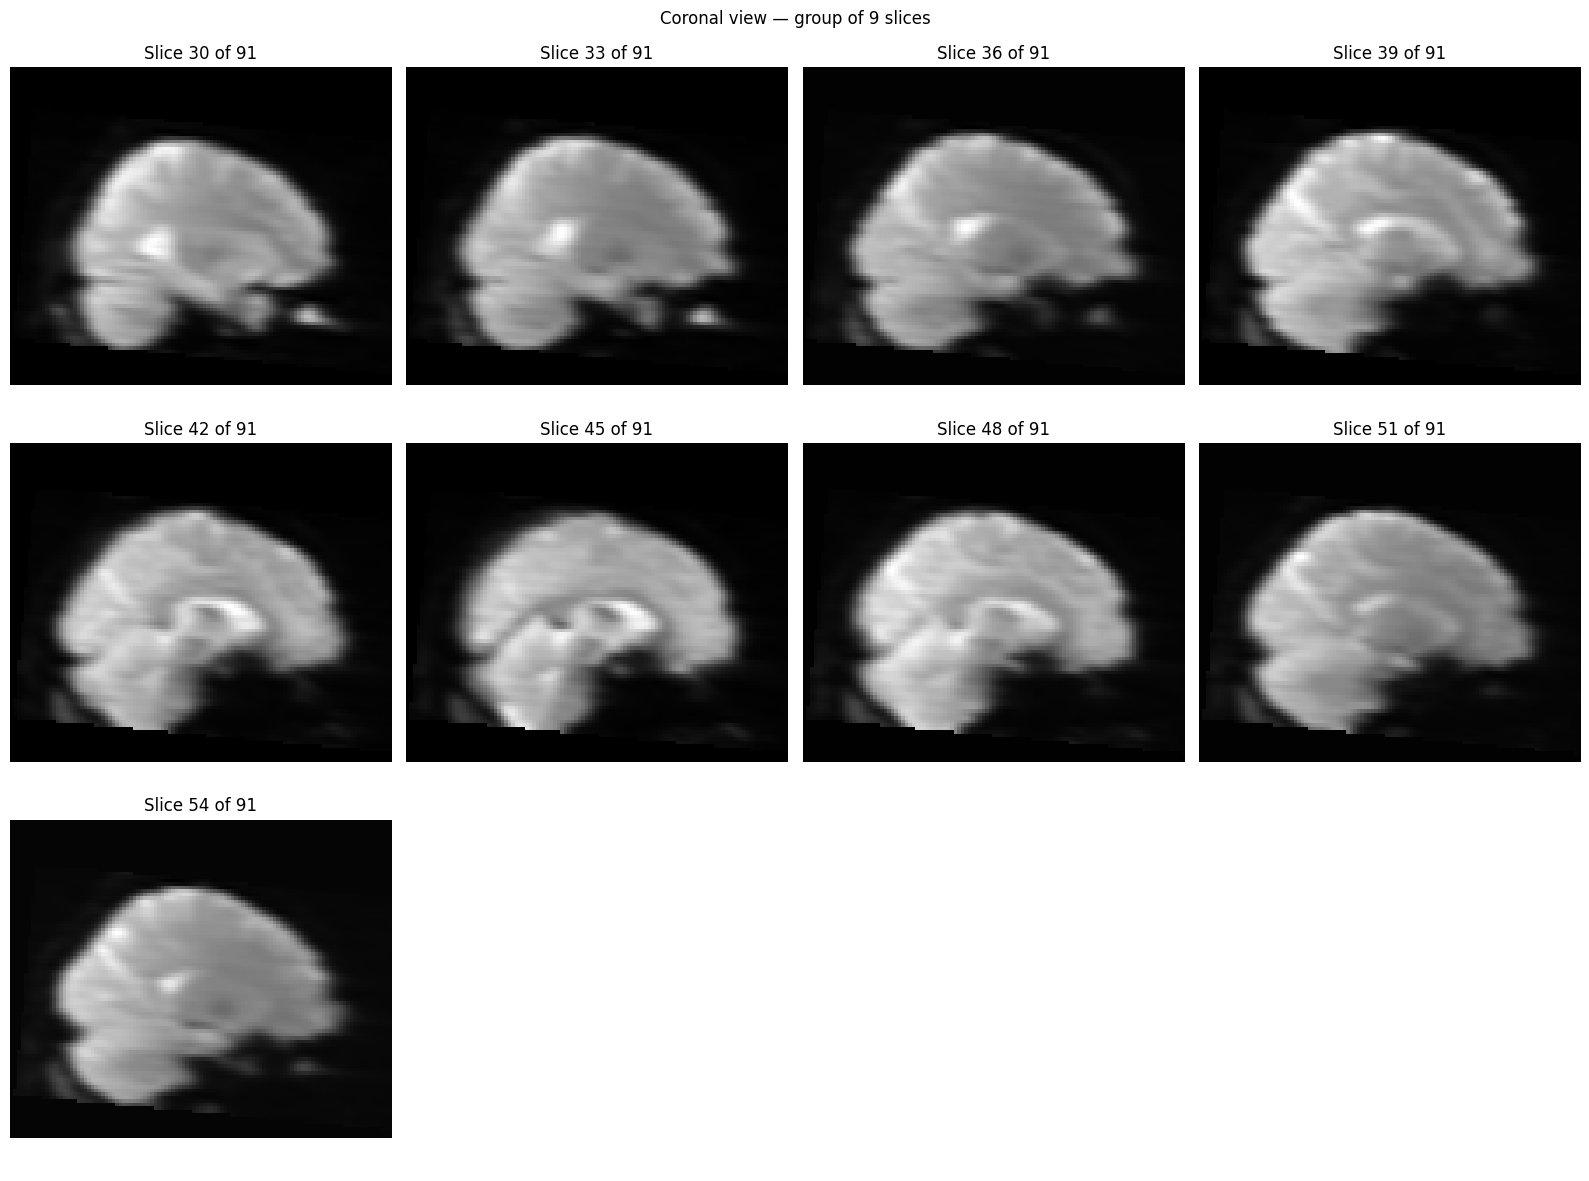

In [6]:
display_group_of_slices(norm_fmri_data, 9, starting_idx=30, disp_step=3, axis='coronal')

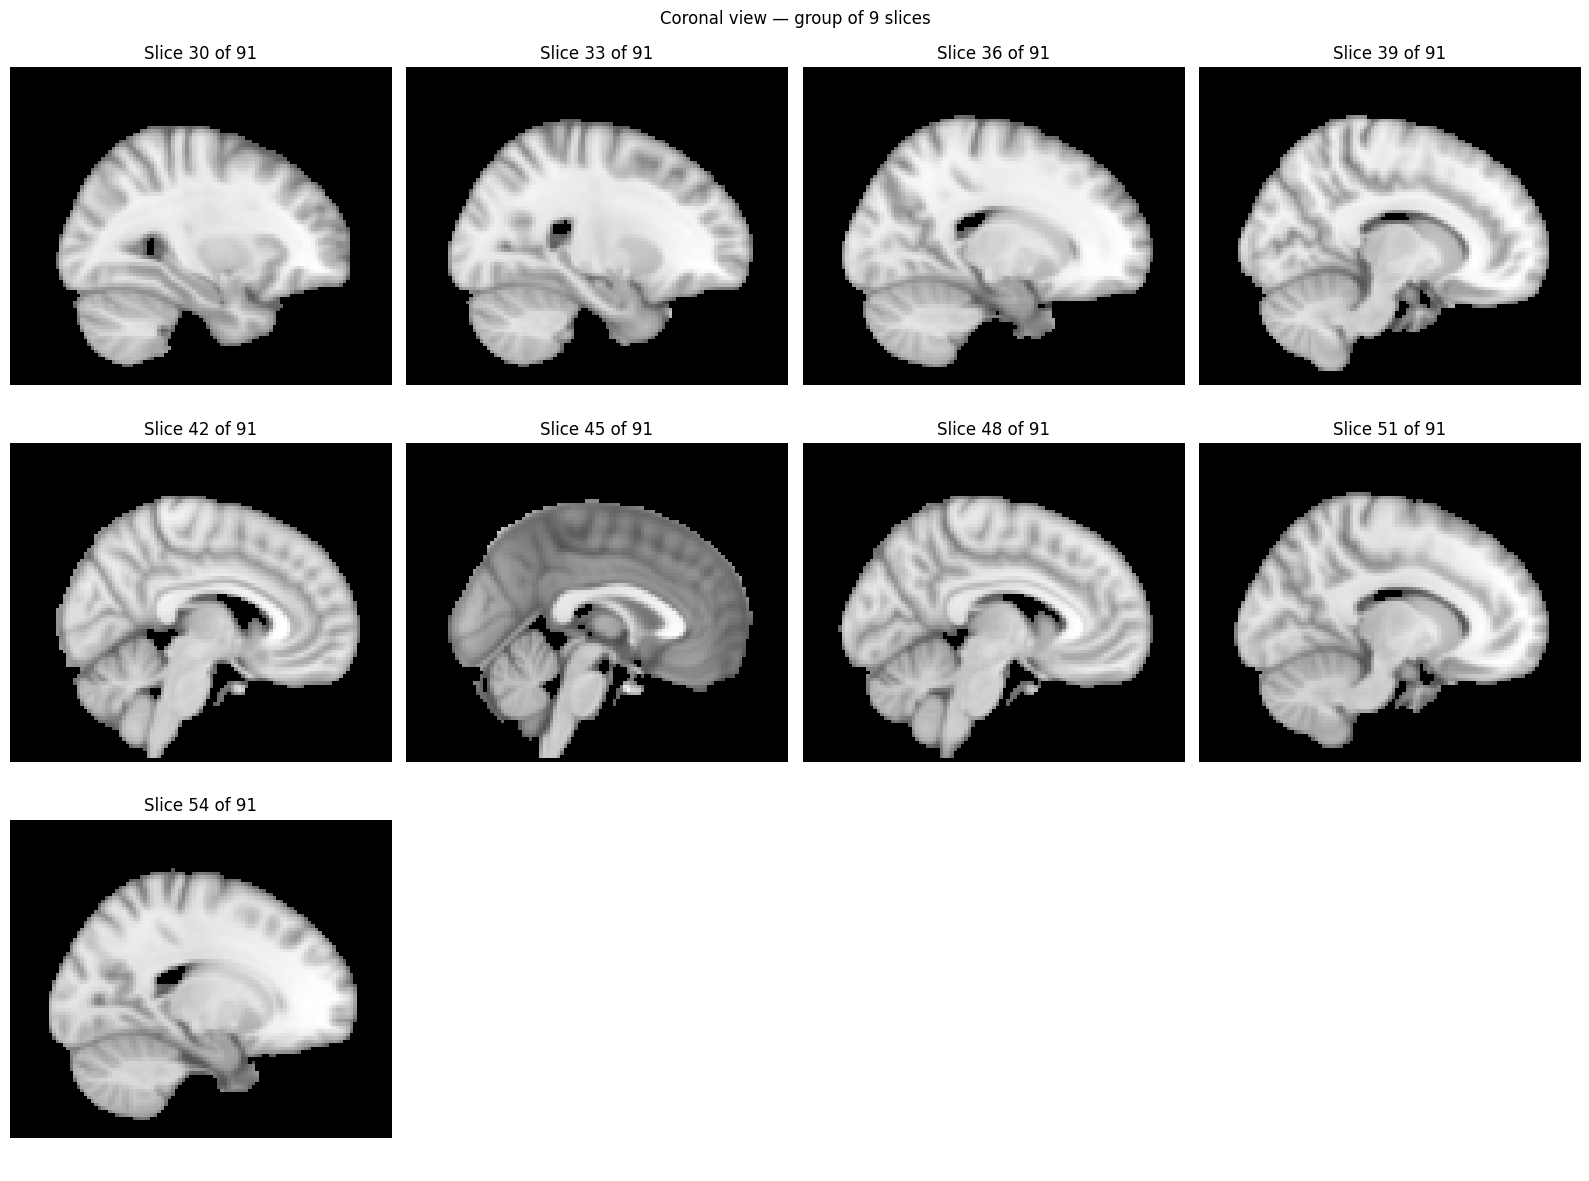

In [7]:
display_group_of_slices(mni_data, 9, starting_idx=30, disp_step=3, axis='coronal')

### Scaletta mentale calcolo serie temporale per ogni label

1) Creazione di una matrice per contenere tutte le maschere (una per ogni label)
2) Creazione matrice 200 x 200 per ospitare per ogni label (200) la time series corrispondente da 200 time step
3) ciclo for sulle label for i in range 1-201
4) estrazione volume norm_fmri relativo alla maschera
5) Medio rispetto all'asse del tempo
6) salvo risultato nella posizione [:,i] (la time series occupa una colonna intera, della i-esima label) salvo nella matrice iniziale 200 x 200

correzione: maschera è meglio calcolarla prima così non calocolo la stessa mascheera 200 volte

In [25]:
masks = np.zeros([200, atlas_data.shape[0],atlas_data.shape[1],atlas_data.shape[2]])
print(masks.shape)

for label_idx in range(1,201):
    mask_i = (atlas_data == label_idx)
    masks[label_idx-1,:,:,:] = mask_i # label 1 va nell'idx 0, label 2 nell'idx 1... e così via

(200, 91, 109, 91)


In [160]:
num_time_pts = norm_fmri_data.shape[3]
num_labels = 200

time_series = np.zeros([num_time_pts, num_labels])
print(time_series.shape)

for label_idx in range(0,200):
    mask = masks[label_idx,:,:,:].astype(bool) # estraggo maschera da usare sul volume di fmri_norm
    voxels_in_roi = norm_fmri_data[mask, :]
    time_series[:, label_idx] = voxels_in_roi.mean(axis=0)
    np.save("time_series.npy",time_series)

print(time_series.shape)

(200, 200)
(200, 200)


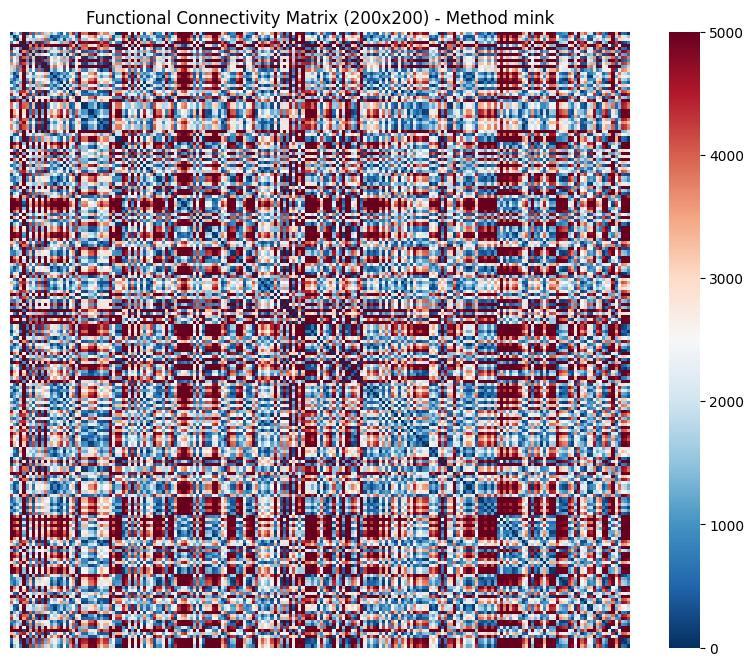

In [159]:
from scipy.stats import spearmanr
from sklearn.metrics.pairwise import euclidean_distances
from scipy.spatial.distance import cdist


def computeAndPlotSimilarity(time_series, distance_measure = 'corr'):

    if distance_measure == 'corr':
        df = pd.DataFrame(time_series, columns=[f"ROI_{i}" for i in range(200)])
        mat = df.corr()

    if distance_measure == 'spearman':
        res = spearmanr(time_series)
        mat = res.statistic

    # Euclidean Distance
    if distance_measure == 'euclidean':
        mat = euclidean_distances(time_series.T,time_series.T)

    if distance_measure == 'cheby':
        mat = cdist(time_series.T, time_series.T, metric='chebyshev')

    if distance_measure == 'mink':
        mat = cdist(time_series.T, time_series.T, metric='minkowski')

    # if distance_measure == 'spearman':
    #     res = spearmanr(time_series)
    #     mat = res.statistic

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        mat,
        cmap="RdBu_r",
        vmin=0,
        vmax=5000,
        annot=False,  # Mai annot=True con 200 ROI
        xticklabels=False,  # Evita scritte sovrapposte illeggibili
        yticklabels=False,
    )
    plt.title(f"Functional Connectivity Matrix (200x200) - Method {distance_measure}")
    plt.show()

computeAndPlotSimilarity(time_series, distance_measure='mink')


In [118]:
# cosa vorrei fare: confrontare + metodi di similarità, potrei partire confrontando direttamente le matrici, oppure confrontando i primi 10 valori + alti con
# entrambi i metodi oppurre contando le occorrenze e vedere se sono coerenti tra più metodi
# magari fare anche una funzione che prende in input una coppia di label o una sola label e mi estrae fuori il nome completo della regione cerebrale

regions_csv = pd.read_csv(REGIONS_CSV_PATH)
df = pd.DataFrame(regions_csv)

def extractRegionNameFromLabel(label_idx, df):

    try:
        region = df.iloc[label_idx-1, 1]
        return region
    except:
        print("Indice non valido per la label")
        return None

region = extractRegionNameFromLabel(100, df)


In [23]:
from sklearn.decomposition import PCA
pca = PCA(n_components=4)
new_data=pca.fit(np.transpose(corr_mat))
print(pca.explained_variance_ratio_)
print(pca.singular_values_)
print(new_data.n_samples_)

[0.60947562 0.34130144 0.03278213 0.01338781]
[78.96872355 59.09435732 18.31451947 11.70392896]
200


In [ ]:
pca = PCA(n_components=4, svd_solver='full')
new_data=pca.fit_transform(np.transpose(corr_mat))
print(pca.explained_variance_ratio_)
print(pca.singular_values_)

[0.60947562 0.34130144 0.03278213 0.01338781]
[78.96872355 59.09435732 18.31451947 11.70392896]


In [ ]:
pca = PCA(n_components=4, svd_solver='arpack')
new_data = pca.fit_transform(np.transpose(corr_mat))
print(pca.explained_variance_ratio_)
print(pca.singular_values_)

[0.60947562 0.34130144 0.03278213 0.01338781]
[78.96872355 59.09435732 18.31451947 11.70392896]


In [24]:
from sklearn.datasets import load_digits
from sklearn.decomposition import FastICA

transformer = FastICA(n_components=7,
        random_state=0,
        whiten='unit-variance')
X_transformed = transformer.fit_transform(corr_mat)
X_transformed.shape

(200, 7)